# First Batch Mini Project: Option 3

### Problem Statement

Here, we write a Qiskit function that takes two inputs: a positive integer $n$ and a matrix $U \in U(2)$ and outputs a quantum circuit on $n+1$ qubits, possibly with further ancillas, that implements a multi controlled $U$ gate, $C^nU$, that is:
$$C^nU|x\rangle_n|y\rangle_1=\begin{cases}\;|x\rangle_nU|y\rangle_1\,, & \text{if } x=(1, 1, \ldots, 1)\\ \;|x\rangle_n|y\rangle_1\,, & \text{otherwise}\end{cases}$$

### Imports

In [63]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import RZGate
from qiskit.quantum_info import random_unitary
from qiskit.quantum_info import Operator
from qiskit.quantum_info import state_fidelity
from qiskit.quantum_info import process_fidelity
from qiskit.quantum_info import Statevector
from itertools import product
from collections import Counter
from qiskit.visualization import plot_histogram
from qiskit import transpile
import pandas as pd

### U Gate Consturction: Linear Ancilla Method

In [64]:
def cn_u_linear_ancilla(n, U):
    if n < 1: raise ValueError("n must be >= 1") # Basic Validation

    U = np.asanyarray(U, dtype=complex)
    if U.shape != (2, 2):
        raise ValueError("We need U to be a 2x2 matrix!")
    
    # Create registers
    controls = QuantumRegister(n, "c")
    target = QuantumRegister(1, "t")

    myQuantumCircuit = QuantumCircuit(controls, target, name=f"C^{n}U")

    U_gate = UnitaryGate(U, label="U")

    if n == 1: #Special case: single control
        myQuantumCircuit.append(U_gate.control(1), [controls[0], target[0]])
        return myQuantumCircuit
    
    ancillas = QuantumRegister(n-1, "a")
    myQuantumCircuit.add_register(ancillas)

    myQuantumCircuit.ccx(controls[0], controls[1], ancillas[0]) # Here, we compute and chain

    for i in range(1, n-1):
        myQuantumCircuit.ccx(ancillas[i-1], controls[i+1], ancillas[i])

    # Application thereof
    myQuantumCircuit.append(U_gate.control(1), [ancillas[n-2], target[0]])

    # Reverse now
    for i in reversed(range(1, n-1)):
        myQuantumCircuit.ccx(ancillas[i - 1], controls[i + 1], ancillas[i])

    myQuantumCircuit.ccx(controls[0], controls[1], ancillas[0])

    return myQuantumCircuit

### Demonstration of Linear Ancilla Method

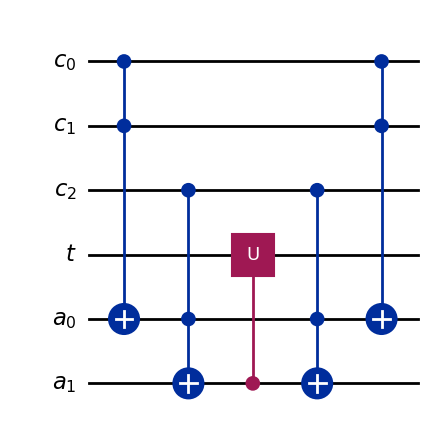

In [65]:
n = 3
U = random_unitary(2).data

thisQuantumCircuit = cn_u_linear_ancilla(n, U)
display(thisQuantumCircuit.draw("mpl"))

### Structural Verification and Basis State Inspection

In [66]:
full_op = Operator(thisQuantumCircuit).data
print("Full matrix shape:", full_op.shape)
print()

num_qubits = thisQuantumCircuit.num_qubits

for bits in product([0, 1], repeat=num_qubits):
    if bits[4] == 0 and bits[5] == 0: print(bits)

Full matrix shape: (64, 64)

(0, 0, 0, 0, 0, 0)
(0, 0, 0, 1, 0, 0)
(0, 0, 1, 0, 0, 0)
(0, 0, 1, 1, 0, 0)
(0, 1, 0, 0, 0, 0)
(0, 1, 0, 1, 0, 0)
(0, 1, 1, 0, 0, 0)
(0, 1, 1, 1, 0, 0)
(1, 0, 0, 0, 0, 0)
(1, 0, 0, 1, 0, 0)
(1, 0, 1, 0, 0, 0)
(1, 0, 1, 1, 0, 0)
(1, 1, 0, 0, 0, 0)
(1, 1, 0, 1, 0, 0)
(1, 1, 1, 0, 0, 0)
(1, 1, 1, 1, 0, 0)


### Functional Correctness Verification

In [67]:
def bits_to_int_qiskit_order(bits):
    idx = 0
    for i, bit in enumerate(bits):
        idx = idx | ((bit & 1) << i)
    return idx

def bits_to_label(bits): # For Qiskit Statevector from label: we need a bitstring label
    return "".join(str(bit) for bit in bits)

def application_to_target_bit(U, tbit): # Application of U to tbit and return resulting 2D statevector on the target bit
    e0 = np.array([1, 0], dtype=complex)
    e1 = np.array([0, 1], dtype=complex)
    if tbit == 0: return U @ e0
    elif tbit == 1: return U @ e1
    else: raise ValueError("tbit must be 0 or 1")

def functional_correctness_check(qc, U, n):
    num_qubits = qc.num_qubits
    target_idx = n
    anc_start = n + 1
    anc_count = n - 1

    trigger_controls = (1, ) * n

    tolerance = 1e-9

    for controls_bits in product([0, 1], repeat=n):
        versatile = 1e-7
        for tbit in [0, 1]:
            bits = list(controls_bits) + [tbit] + [0] * anc_count
            sv_in = Statevector.from_int(bits_to_int_qiskit_order(bits), 2**num_qubits)
            sv_out = sv_in.evolve(qc)

            ancilla_indices = list(range(anc_start, anc_start + anc_count))
            anc_probs = sv_out.probabilities(qargs=ancilla_indices)
            prob_anc0 = anc_probs[0]

            if abs(prob_anc0 - 1.0) > tolerance:
                return False, f"Ancillas not cleaned for the following: controls={controls_bits}, tbit={tbit}, and prob_anc0={prob_anc0}"
            
            if controls_bits != trigger_controls:
                inner_dinner = np.vdot(sv_in.data, sv_out.data)
                if abs(inner_dinner) < tolerance: return False, "Notice that we triggered case orthogonal for controls of "+str(controls_bits)+" and target bit "+str(tbit)+"."
                pphase = inner_dinner / np.abs(inner_dinner)
                if np.linalg.norm(sv_out.data - pphase * sv_in.data) > versatile: return False, f"Unexpected output for controls={controls_bits} and tbit={tbit}."
            else:
                ut = application_to_target_bit(U, tbit)
                b00 = list(controls_bits) + [0] + [0] * anc_count
                b11 = list(controls_bits) + [1] + [0] * anc_count
                drew_McINTYRE = (ut[0] * Statevector.from_int(bits_to_int_qiskit_order(b00), 2**num_qubits) + ut[1] * Statevector.from_int(bits_to_int_qiskit_order(b11), 2**num_qubits))
                luka_DONCIC = np.vdot(drew_McINTYRE.data, sv_out.data)
                if abs(luka_DONCIC) < tolerance: return False, "Notice that we triggered case output orthogonal for controls of "+str(controls_bits)+" and target bit "+str(tbit)+"."
                my_phase = luka_DONCIC / np.abs(luka_DONCIC)
                kemp_tolerance = 1e-7
                if np.linalg.norm(sv_out.data - my_phase * drew_McINTYRE.data) > kemp_tolerance: return False, "Triggered case mismatch for control bits and target bit "+str((controls_bits, tbit))
    
    return True, "All cases passed functional correctness check!"


### Verify Functional Correctness Check

In [68]:
n = 3
matrix_U = random_unitary(2).data
qc = cn_u_linear_ancilla(n, matrix_U)

okay, message = functional_correctness_check(qc, matrix_U, n)
print(okay)
print(message)

True
All cases passed functional correctness check!


### Resource Analysis

We first check the Qubit count:
$$Q_{\text{total}}=n_{\text{controls}}+\tau+(n-1)_\text{ancilla}$$
$$\text{We have $1$ target qubit. We call $\tau$ as the target.}$$
$$Q_{\text{total}}=n+1+n-1$$
$$Q_{\text{total}}=2n$$
Thus, our Qubit count is $2n$.<br><br>

For our Gate Count, we have $n-1$ Toffoli Gate when we forward compute, $n-1$ Toffoli Gate when we reverse uncompute, and one controlled U Gate. This leaves us with the Toffoli Count of $2(n-1)$ and $2(n-1)+1$ total multi qubit gates.<br>
We observe $\mathcal{O}(n)$ Depth.

### Resource Allocation

For qubits, controls encode conditional logic. Furthermore, ancillas accumulate the logical $\land$ of control bits, where the final ancilla acts as a global trigger. The target receives $U$ conditioned on trigger. We further Compute, Apply, and Uncompute. Forward Toffoli chain computes global $\land$. We also intend for no garbages states, reversibility, and clean ancilla reset. Linear ancillas provide: linear depth, simple architecture, and clean scaling.

### Benchmarking

In [69]:
def benchmark_cn_u_linear_ancilla(n_values, my_basis_gates=("u", "cx"), opt_level=1):
    raw_metrics = {}
    transpiled_metrics = {}

    for n in n_values:
        U = random_unitary(2).data
        qc = cn_u_linear_ancilla(n, U)

        raw_ops = Counter({str(k): int(v) for k, v in qc.count_ops().items()})
        raw_metrics[n] = {
            "qubits": qc.num_qubits,
            "depth": qc.depth(),
            "size": qc.size(),
            "ccx": raw_ops.get("ccx", 0),
            "ops": raw_ops,
        }

        tqc = transpile(qc, basis_gates=list(my_basis_gates), optimization_level=opt_level)
        t_ops = Counter({str(k): int(v) for k, v in tqc.count_ops().items()})
        transpiled_metrics[n] = {
            "qubits": tqc.num_qubits,
            "depth": tqc.depth(),
            "size": tqc.size(),
            "cx": t_ops.get("cx", 0),
            "u": t_ops.get("u", 0),
            "ops": t_ops,
        }

    return raw_metrics, transpiled_metrics

def print_benchmark_table_pd(raw_metrics, transpiled_metrics):
    raw_rows = []
    for n in sorted(raw_metrics):
        m = raw_metrics[n]
        raw_rows.append({
            "n": n,
            "qubits": m["qubits"],
            "depth": m["depth"],
            "size": m["size"],
            "ccx": m["ccx"]
        })
    
    raw_df = pd.DataFrame(raw_rows).set_index("n")
    
    transpiled_rows = []
    for n in sorted(transpiled_metrics):
        m = transpiled_metrics[n]
        transpiled_rows.append({
            "n": n,
            "qubits": m["qubits"],
            "depth": m["depth"],
            "size": m["size"],
            "cx": m["cx"],
            "u": m["u"]
        })
    
    transpiled_df = pd.DataFrame(transpiled_rows).set_index("n")
    
    print("=== Benchmark Table (Raw Circuit) ===")
    display(raw_df)
    
    print("\n=== Benchmark Table (Transpiled Circuit) ===")
    display(transpiled_df)
    
    return raw_df, transpiled_df

def plot_benchmark_histograms(raw_metrics, transpiled_metrics): # Showcase raw plots and transpiled plots

    depth_dict = {f"n={n}": raw_metrics[n]["depth"] for n in sorted(raw_metrics)}
    ccx_dict   = {f"n={n}": raw_metrics[n]["ccx"]   for n in sorted(raw_metrics)}
    size_dict  = {f"n={n}": raw_metrics[n]["size"]  for n in sorted(raw_metrics)}

    display(plot_histogram(depth_dict, title="Raw Depth vs n"))
    display(plot_histogram(ccx_dict, title="Raw CCX Count vs n"))
    display(plot_histogram(size_dict, title="Raw Size (#ops) vs n"))

    t_depth_dict = {f"n={n}": transpiled_metrics[n]["depth"] for n in sorted(transpiled_metrics)}
    cx_dict      = {f"n={n}": transpiled_metrics[n]["cx"]    for n in sorted(transpiled_metrics)}
    u_dict       = {f"n={n}": transpiled_metrics[n]["u"]     for n in sorted(transpiled_metrics)}

    display(plot_histogram(t_depth_dict, title="Transpiled Depth vs n (basis u,cx)"))
    display(plot_histogram(cx_dict, title="Transpiled CX Count vs n (basis u,cx)"))
    display(plot_histogram(u_dict, title="Transpiled U Count vs n (basis u,cx)"))

### Run Benchmark

=== Benchmark Table (Raw Circuit) ===


,qubits,depth,size,ccx
n,,,,
2,4,3,3,2
3,6,5,5,4
4,8,7,7,6
5,10,9,9,8
6,12,11,11,10
7,14,13,13,12
8,16,15,15,14
9,18,17,17,16
10,20,19,19,18



=== Benchmark Table (Transpiled Circuit) ===


,qubits,depth,size,cx,u
n,,,,,
2,4,23,34,14,20
3,6,40,62,26,36
4,8,57,90,38,52
5,10,74,118,50,68
6,12,91,146,62,84
7,14,108,174,74,100
8,16,125,202,86,116
9,18,142,230,98,132
10,20,159,258,110,148


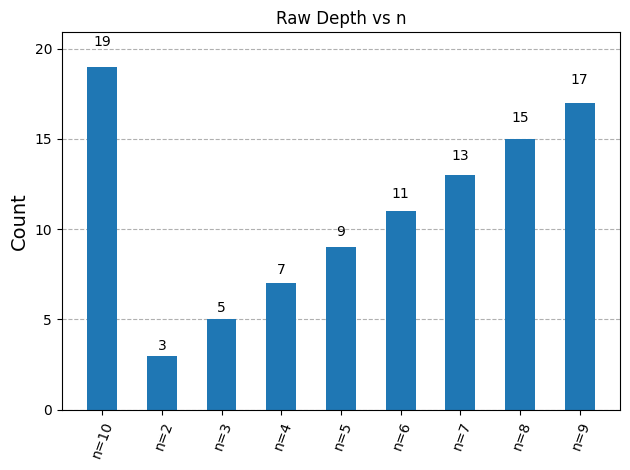

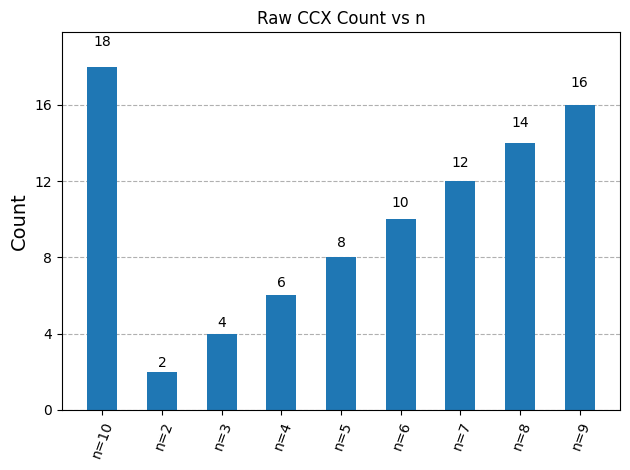

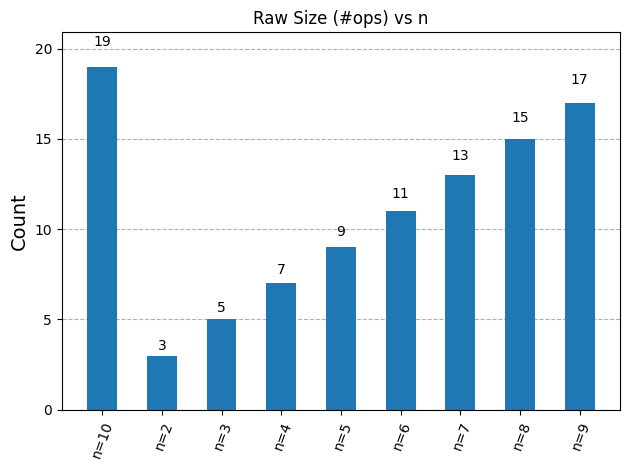

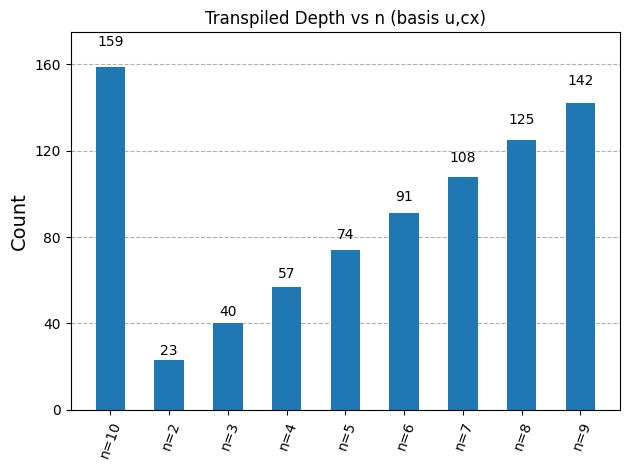

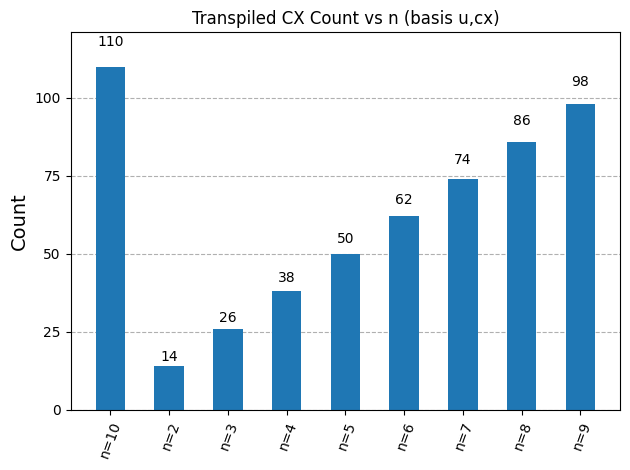

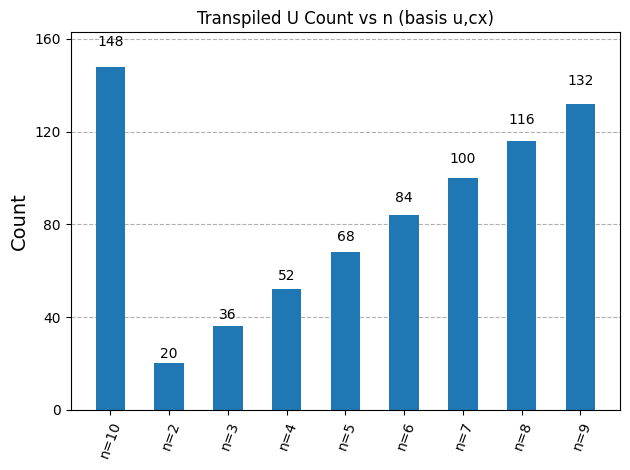

In [70]:
n_values = list(range(2, 11))   # n = 2..10
raw_metrics, transpiled_metrics = benchmark_cn_u_linear_ancilla(n_values, my_basis_gates=("u","cx"), opt_level=1)

raw_df, transpiled_df = print_benchmark_table_pd(raw_metrics, transpiled_metrics)
plot_benchmark_histograms(raw_metrics, transpiled_metrics)

### Application: Multi Controlled $Z$ as a Grover style Oracle

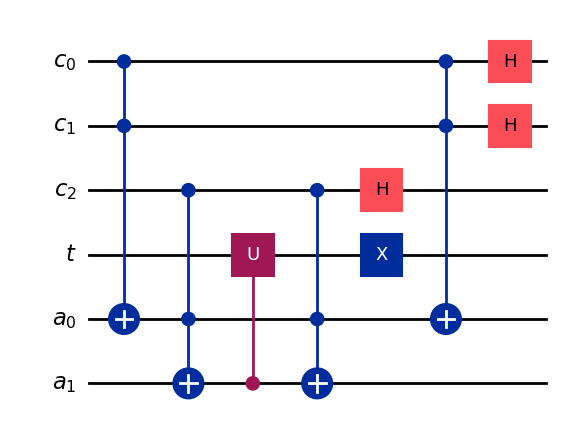

In [71]:
n = 3
Z = np.array([[1, 0], [0, -1]], dtype=complex)

qc_oracle = cn_u_linear_ancilla(n, Z)

anc_count = n - 1
num_qubits = 2*n

sv_in = Statevector.from_int(0, 2**num_qubits)

for i in range(n):
    qc_oracle.h(i)
qc_oracle.x(n)

sv_out = sv_in.evolve(qc_oracle)

bits_zeros = [0]*n + [1] + [0]*anc_count
bits_ones  = [1]*n + [1] + [0]*anc_count

amp_zeros = sv_out.data[bits_to_int_qiskit_order(bits_zeros)]
amp_ones  = sv_out.data[bits_to_int_qiskit_order(bits_ones)]

display(qc_oracle.draw("mpl"))